<a href="https://colab.research.google.com/github/75somu/FUTURE_ML_02/blob/main/ticket_classifier_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎫 Task 2 — Support Ticket Classification System
### Future Interns ML Project
**Goal:** Automatically classify customer support tickets by **Category** and **Priority** using NLP + Machine Learning

---
**Pipeline:**
`Raw Text → Clean Text → TF-IDF Features → ML Model → Category + Priority`

---
### ▶️ How to Run
Click on each cell and press **Shift + Enter** to run it one by one from top to bottom.

## 📦 STEP 1 — Upload Kaggle API Key

In [2]:
import os, json

# ── Fill in your details below ────────────────────────────
KAGGLE_USERNAME  = "https://www.kaggle.com/somukarthik"              # 👈 your Kaggle username
KAGGLE_API_TOKEN = "KGAT_b670d6f45e6df2e3fb7997d7e9aa8dcd"  # 👈 your token

# Create kaggle.json automatically
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_API_TOKEN}, f)

os.chmod('/root/.kaggle/kaggle.json', 600)
print("✅ Kaggle setup complete!")

✅ Kaggle setup complete!


## 📥 STEP 2 — Download Dataset from Kaggle

In [3]:
# ── Download and Extract Dataset ──────────────────────────
import zipfile
import os

print('⬇️  Downloading dataset from Kaggle...')
!kaggle datasets download -d suraj520/customer-support-ticket-dataset

print('\n📦 Extracting files...')
with zipfile.ZipFile('customer-support-ticket-dataset.zip', 'r') as z:
    z.extractall('.')

print('\n✅ Done! Files available:')
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f'   📄 {f}')

⬇️  Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset
License(s): CC0-1.0
  0% 0.00/828k [00:00<?, ?B/s]
100% 828k/828k [00:00<00:00, 691MB/s]

📦 Extracting files...

✅ Done! Files available:
   📄 customer_support_tickets.csv


## 📚 STEP 3 — Import All Libraries

In [4]:
# ── All Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('\n✅ All libraries loaded successfully!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



✅ All libraries loaded successfully!


## 📂 STEP 4 — Load and Explore the Dataset

In [5]:
# ── Auto-detect CSV filename and Load ─────────────────────
import glob

# Automatically find the CSV file
csv_files = glob.glob('*.csv')
print('CSV files found:', csv_files)

# Load the first CSV found
df = pd.read_csv(csv_files[0])

print(f'\n✅ Loaded: {csv_files[0]}')
print(f'Shape   : {df.shape}')
print(f'\nColumn Names:')
for col in df.columns:
    print(f'   • {col}')

print('\nFirst 3 rows:')
df.head(3)

CSV files found: ['customer_support_tickets.csv']

✅ Loaded: customer_support_tickets.csv
Shape   : (8469, 17)

Column Names:
   • Ticket ID
   • Customer Name
   • Customer Email
   • Customer Age
   • Customer Gender
   • Product Purchased
   • Date of Purchase
   • Ticket Type
   • Ticket Subject
   • Ticket Description
   • Ticket Status
   • Resolution
   • Ticket Priority
   • Ticket Channel
   • First Response Time
   • Time to Resolution
   • Customer Satisfaction Rating

First 3 rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [6]:
# ── Check Missing Values ──────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal rows: {len(df)}')

Missing values per column:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Total rows: 8469


## 🧹 STEP 5 — Select and Clean Columns

In [7]:
# ── Select Relevant Columns ───────────────────────────────
# We only need 3 columns:
# 'Ticket Description' = the customer's message (input)
# 'Ticket Type'        = category label (output 1)
# 'Ticket Priority'    = priority label (output 2)

df = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']].copy()

# Rename for easier use
df.columns = ['text', 'category', 'priority']

# Drop rows with missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset size after cleaning: {len(df)} rows')
print('\nCategory distribution:')
print(df['category'].value_counts())
print('\nPriority distribution:')
print(df['priority'].value_counts())

Dataset size after cleaning: 8469 rows

Category distribution:
category
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Priority distribution:
priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


## 📊 STEP 6 — Visualize the Data

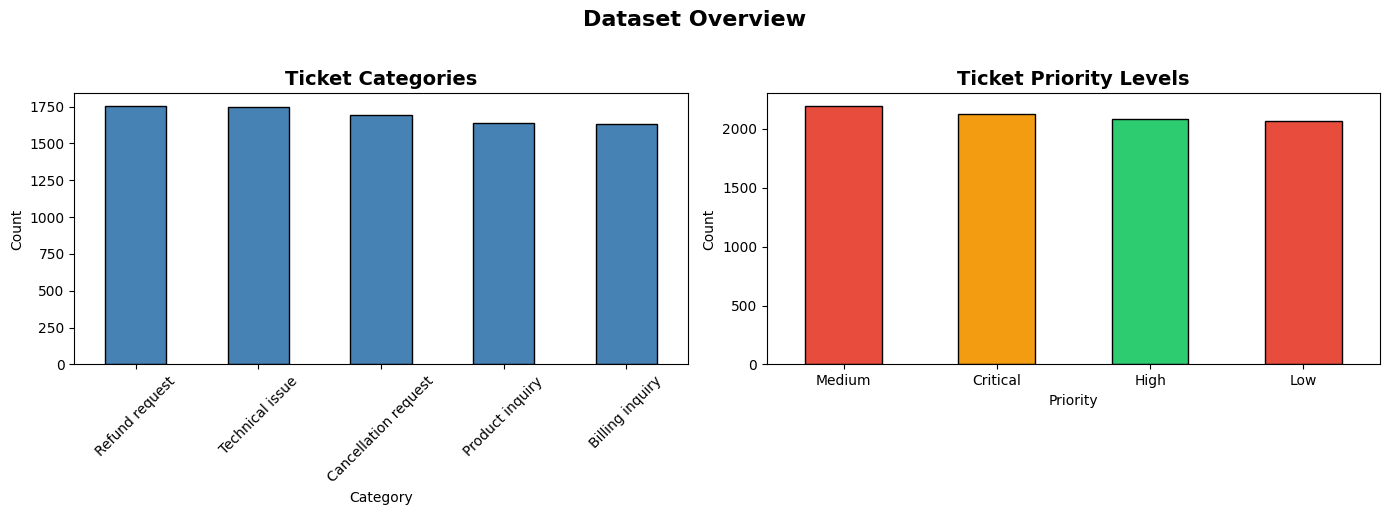

✅ Chart saved as class_distribution.png


In [8]:
# ── Visualize Class Distributions ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category chart
df['category'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Ticket Categories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Priority chart
colors = ['#e74c3c', '#f39c12', '#2ecc71']
df['priority'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=colors[:len(df['priority'].unique())],
    edgecolor='black'
)
axes[1].set_title('Ticket Priority Levels', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Dataset Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as class_distribution.png')

## 🔤 STEP 7 — Text Cleaning (NLP Preprocessing)

In [9]:
# ── Text Cleaning Function ────────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Cleans raw ticket text through 5 steps:
    1. Lowercase everything
    2. Remove URLs, emails, numbers, punctuation
    3. Tokenize (split into words)
    4. Remove stopwords (the, is, at, which...)
    5. Lemmatize (running -> run, better -> good)
    """
    if not isinstance(text, str):
        return ''

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove noise
    text = re.sub(r'http\S+|www\S+', '', text)    # Remove URLs
    text = re.sub(r'\S+@\S+', '', text)            # Remove emails
    text = re.sub(r'\d+', '', text)                # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)            # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra spaces

    # Steps 3, 4 & 5: Tokenize, remove stopwords, lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(tokens)

# Apply cleaning to all tickets
print('🔄 Cleaning text... please wait...')
df['clean_text'] = df['text'].apply(clean_text)

# Show before/after example
print('\n--- ORIGINAL TEXT ---')
print(df['text'].iloc[0])
print('\n--- CLEANED TEXT ---')
print(df['clean_text'].iloc[0])
print('\n✅ Text cleaning complete!')

🔄 Cleaning text... please wait...

--- ORIGINAL TEXT ---
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

--- CLEANED TEXT ---
issue product_purchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists

✅ Text cleaning complete!


## 🔢 STEP 8 — Feature Extraction with TF-IDF

In [10]:
# ── TF-IDF Vectorization ──────────────────────────────────
# TF-IDF converts text into numbers that ML models understand
# Words that are unique/important to a ticket get higher scores

tfidf = TfidfVectorizer(
    max_features=5000,    # Top 5000 most important words
    ngram_range=(1, 2),   # Single words AND two-word phrases
    min_df=2,             # Ignore words in fewer than 2 tickets
    sublinear_tf=True     # Apply log normalization
)

X = tfidf.fit_transform(df['clean_text'])

print(f'✅ Feature matrix shape: {X.shape}')
print(f'   Rows    = number of tickets')
print(f'   Columns = number of word features')
print(f'\nSample important words:')
print(list(tfidf.get_feature_names_out()[:20]))

✅ Feature matrix shape: (8469, 5000)
   Rows    = number of tickets
   Columns = number of word features

Sample important words:
['ability', 'able', 'able accept', 'able add', 'able answer', 'able connect', 'able contact', 'able find', 'able fix', 'able get', 'able help', 'able ive', 'able make', 'able purchase', 'able see', 'able sell', 'able use', 'able view', 'absolutely', 'accept']


## ✂️ STEP 9 — Encode Labels and Split Data

In [11]:
# ── Encode Labels ─────────────────────────────────────────
# ML models need numbers, not text labels
# e.g. Billing=0, Technical=1, Account=2

le_cat = LabelEncoder()
y_category = le_cat.fit_transform(df['category'])

le_pri = LabelEncoder()
y_priority = le_pri.fit_transform(df['priority'])

print('Category classes:', list(le_cat.classes_))
print('Priority classes :', list(le_pri.classes_))

# ── Split: 80% Training, 20% Testing ─────────────────────
X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X, y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

_, _, y_pri_train, y_pri_test = train_test_split(
    X, y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print('\n✅ Data split complete!')

Category classes: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']
Priority classes : ['Critical', 'High', 'Low', 'Medium']

Training samples : 6775
Testing samples  : 1694

✅ Data split complete!


## 🤖 STEP 10 — Train the ML Models

In [12]:
# ── Train Category Classifier ─────────────────────────────
print('🔄 Training Category model...')
cat_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42
)
cat_model.fit(X_train, y_cat_train)
print('✅ Category model trained!')

# ── Train Priority Classifier ─────────────────────────────
print('\n🔄 Training Priority model...')
pri_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42
)
pri_model.fit(X_train, y_pri_train)
print('✅ Priority model trained!')

print('\n🎉 Both models trained successfully!')

🔄 Training Category model...
✅ Category model trained!

🔄 Training Priority model...
✅ Priority model trained!

🎉 Both models trained successfully!


## 📈 STEP 11 — Evaluate Model Performance

In [13]:
# ── Evaluation Function ───────────────────────────────────
def evaluate_model(model, X_test, y_test, label_encoder, title):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f'\n{"="*55}')
    print(f'  {title}')
    print(f'{"="*55}')
    print(f'  Overall Accuracy: {acc:.2%}')
    print(f'\n  Detailed Report (per class):')
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_
    ))
    return y_pred

# Evaluate both models
y_cat_pred = evaluate_model(
    cat_model, X_test, y_cat_test, le_cat,
    'CATEGORY CLASSIFICATION RESULTS'
)

y_pri_pred = evaluate_model(
    pri_model, X_test, y_pri_test, le_pri,
    'PRIORITY CLASSIFICATION RESULTS'
)


  CATEGORY CLASSIFICATION RESULTS
  Overall Accuracy: 20.31%

  Detailed Report (per class):
                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.21      0.20       327
Cancellation request       0.21      0.21      0.21       339
     Product inquiry       0.21      0.25      0.22       328
      Refund request       0.18      0.17      0.18       351
     Technical issue       0.23      0.18      0.20       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694


  PRIORITY CLASSIFICATION RESULTS
  Overall Accuracy: 24.20%

  Detailed Report (per class):
              precision    recall  f1-score   support

    Critical       0.25      0.24      0.24       426
        High       0.26      0.28      0.27       417
         Low       0.24      0.26      0.25       413
      Medium       0.22      0.20 

## 🔲 STEP 12 — Confusion Matrices

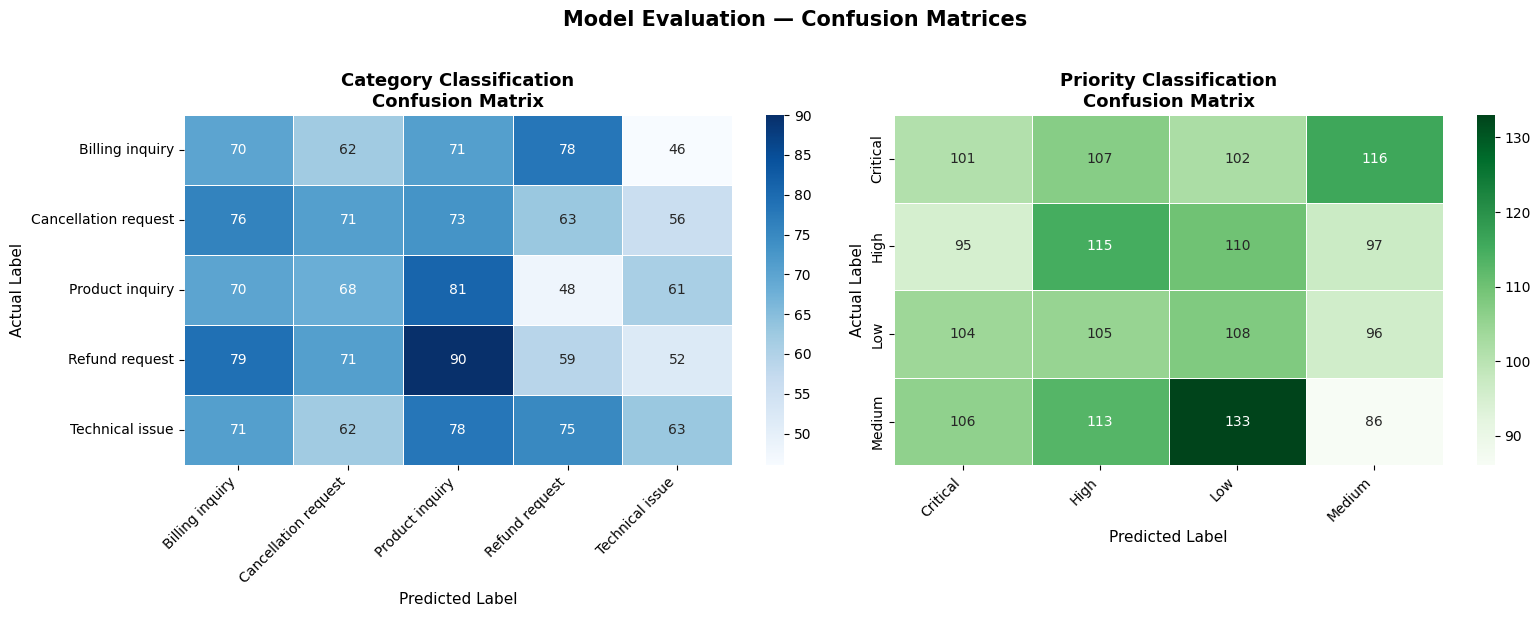

✅ Confusion matrices saved!


In [14]:
# ── Confusion Matrices ────────────────────────────────────
# Shows which categories are being confused with each other
# Dark diagonal = good predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_configs = [
    (axes[0], y_cat_test, y_cat_pred, le_cat, 'Category Classification', 'Blues'),
    (axes[1], y_pri_test, y_pri_pred, le_pri, 'Priority Classification', 'Greens')
]

for ax, y_true, y_pred, le, title, cmap in plot_configs:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Model Evaluation — Confusion Matrices',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved!')

## 🎯 STEP 13 — Live Ticket Prediction

In [15]:
# ── Live Prediction Function ──────────────────────────────
def classify_ticket(ticket_text):
    """
    Takes a raw support ticket and returns
    predicted category and priority with confidence score.
    """
    # Clean and vectorize the input
    cleaned    = clean_text(ticket_text)
    vectorized = tfidf.transform([cleaned])

    # Predict category and priority
    category = le_cat.inverse_transform(cat_model.predict(vectorized))[0]
    priority = le_pri.inverse_transform(pri_model.predict(vectorized))[0]

    # Get confidence scores
    cat_conf = cat_model.predict_proba(vectorized).max() * 100
    pri_conf = pri_model.predict_proba(vectorized).max() * 100

    # Display result
    ticket_display = ticket_text[:75] + '...' if len(ticket_text) > 75 else ticket_text
    print(f'\n{"─"*60}')
    print(f'📩  TICKET   : {ticket_display}')
    print(f'📂  Category : {category:<25} ({cat_conf:.0f}% confident)')
    print(f'🚨  Priority : {priority:<25} ({pri_conf:.0f}% confident)')
    print(f'{"─"*60}')

# ── Test with sample tickets ──────────────────────────────
print('🔍 LIVE TICKET CLASSIFICATION DEMO')
print('=' * 60)

sample_tickets = [
    "I was charged twice for my subscription this month, need refund",
    "The app keeps crashing every time I try to upload a file",
    "Can you tell me what payment methods you accept?",
    "My account has been hacked, someone changed my email and password",
    "I want to cancel my subscription and get a full refund",
    "Dashboard is not loading and showing error 500 on every page"
]

for ticket in sample_tickets:
    classify_ticket(ticket)

🔍 LIVE TICKET CLASSIFICATION DEMO

────────────────────────────────────────────────────────────
📩  TICKET   : I was charged twice for my subscription this month, need refund
📂  Category : Product inquiry           (32% confident)
🚨  Priority : High                      (36% confident)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
📩  TICKET   : The app keeps crashing every time I try to upload a file
📂  Category : Product inquiry           (27% confident)
🚨  Priority : Critical                  (32% confident)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
📩  TICKET   : Can you tell me what payment methods you accept?
📂  Category : Technical issue           (40% confident)
🚨  Priority : Critical                  (27% confident)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────

## 💾 STEP 14 — Save the Models

In [16]:
# ── Save All Model Files ──────────────────────────────────
import joblib

joblib.dump(cat_model, 'category_model.pkl')
joblib.dump(pri_model, 'priority_model.pkl')
joblib.dump(tfidf,     'tfidf_vectorizer.pkl')
joblib.dump(le_cat,    'label_encoder_category.pkl')
joblib.dump(le_pri,    'label_encoder_priority.pkl')

print('✅ All model files saved!')
print('\nSaved files:')
print('  • category_model.pkl')
print('  • priority_model.pkl')
print('  • tfidf_vectorizer.pkl')
print('  • label_encoder_category.pkl')
print('  • label_encoder_priority.pkl')

✅ All model files saved!

Saved files:
  • category_model.pkl
  • priority_model.pkl
  • tfidf_vectorizer.pkl
  • label_encoder_category.pkl
  • label_encoder_priority.pkl


## 📥 STEP 15 — Download All Files to Your PC

In [17]:
# ── Download Output Files from Colab to Your PC ───────────
from google.colab import files

download_files = [
    'class_distribution.png',
    'confusion_matrices.png',
    'category_model.pkl',
    'priority_model.pkl',
    'tfidf_vectorizer.pkl',
    'label_encoder_category.pkl',
    'label_encoder_priority.pkl'
]

for file in download_files:
    try:
        files.download(file)
        print(f'✅ Downloaded: {file}')
    except Exception as e:
        print(f'⚠️  Could not download {file}: {e}')

print('\n🎉 All done! Upload these files to your GitHub repository.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: label_encoder_category.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: label_encoder_priority.pkl

🎉 All done! Upload these files to your GitHub repository.


---
## ✅ Project Completion Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Kaggle API key uploaded | ✅ |
| 2 | Dataset downloaded from Kaggle | ✅ |
| 3 | Libraries imported | ✅ |
| 4 | Data loaded and explored | ✅ |
| 5 | Columns selected and cleaned | ✅ |
| 6 | Data visualized (charts) | ✅ |
| 7 | Text cleaned with NLTK | ✅ |
| 8 | TF-IDF features extracted | ✅ |
| 9 | Labels encoded, data split 80/20 | ✅ |
| 10 | Two ML models trained | ✅ |
| 11 | Models evaluated with metrics | ✅ |
| 12 | Confusion matrices plotted | ✅ |
| 13 | Live prediction system working | ✅ |
| 14 | Models saved as .pkl files | ✅ |
| 15 | Files downloaded to PC | ✅ |

---
### 🚀 Built for Future Interns — Task 2
**Tech Stack:** Python · scikit-learn · NLTK · pandas · matplotlib · seaborn

**Next Steps:**
- Upload this notebook + saved files to your GitHub repository
- Share on LinkedIn and tag Future Interns